#**EXPERIMENT NUMBER 2**
##Harshul Bhatt
**21B030015**

# Mach-Zehnder Interferometer Experiment

**Objective:** To assemble a Mach-Zehnder interferometer to observe the interference pattern and determine the refractive index of air as a function of pressure.

**Background:** The Mach-Zehnder interferometer is used to demonstrate interference by amplitude splitting. A coherent light beam is split into two parts, and these partial beams travel along different paths. They are then recombined to produce interference patterns. By varying the air pressure in one arm of the interferometer, the refractive index of air can be measured as it affects the optical path length.



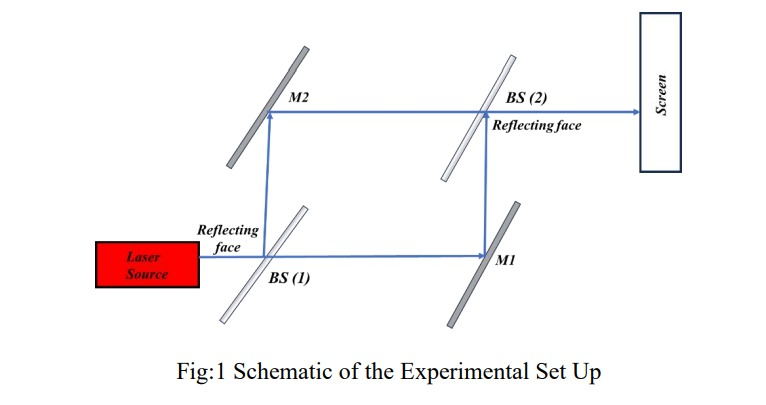

## Apparatus and Setup

**Equipment:**
- Laser Optics Base Plate
- Diode Laser with Laser Mount
- 2 Beam Splitters with Mounts
- 2 Plane Mirrors Mounted on Translational Stage
- Pressure Cell
- Screen
- Pressure Gauge
- Pressure Pump

**Setup Procedure:**
1. Mount the laser on the laser support and adjust it to ensure the beam travels perfectly horizontally.
2. Position the first beam splitter (BS1) at a 45° angle to split the beam into two orthogonal paths.
3. Place mirrors M1 and M2 to reflect the beams towards the second beam splitter (BS2), ensuring the beams are recombined and interfere on the screen.
4. Adjust the components carefully to align the beams and produce a clear interference pattern on the screen.


## Theory

Optical interference occurs when two light waves combine to form a resultant wave of greater, lower, or the same amplitude. The Mach-Zehnder interferometer splits a light beam into two paths, and the recombined beams produce an interference pattern based on the relative phase acquired along the paths.

When the pressure is changed in one of the arms, the refractive index of air changes, altering the optical path length. The change in refractive index $ \Delta n $ is related to the fringe shift $ m $ by the formula:

$$
\Delta n = \frac{m \lambda}{L}
$$

The refractive index of air  $n$ as a function of pressure $ p $ is given by:

$$
n = 1 + kp
$$

where $ k $ is a constant. The number of fringes shifted $ m $ is related to the change in pressure $ \Delta p $ by:

$$
\Delta p = \frac{m \lambda}{L k}
$$

To find $ k $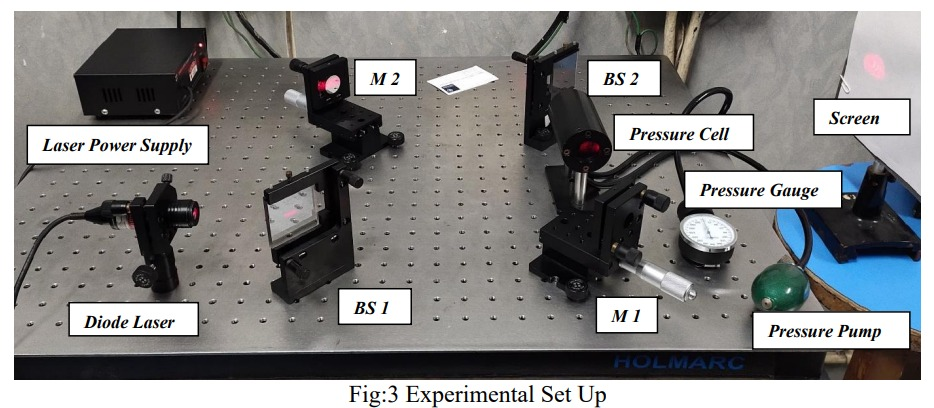, we use the slope from a plot of fringe shift versus pressure:

$$
k = \frac{-\lambda}{L \cdot \text{slope}}
$$


## Data Collection

1. Place the pressure cell in one arm of the interferometer.
2. Adjust the pressure using the pressure pump and control valve.
3. Gradually release the pressure and count the number of fringes shifted.
4. Record the pressure and corresponding fringe shift. Repeat for at least five different pressures.
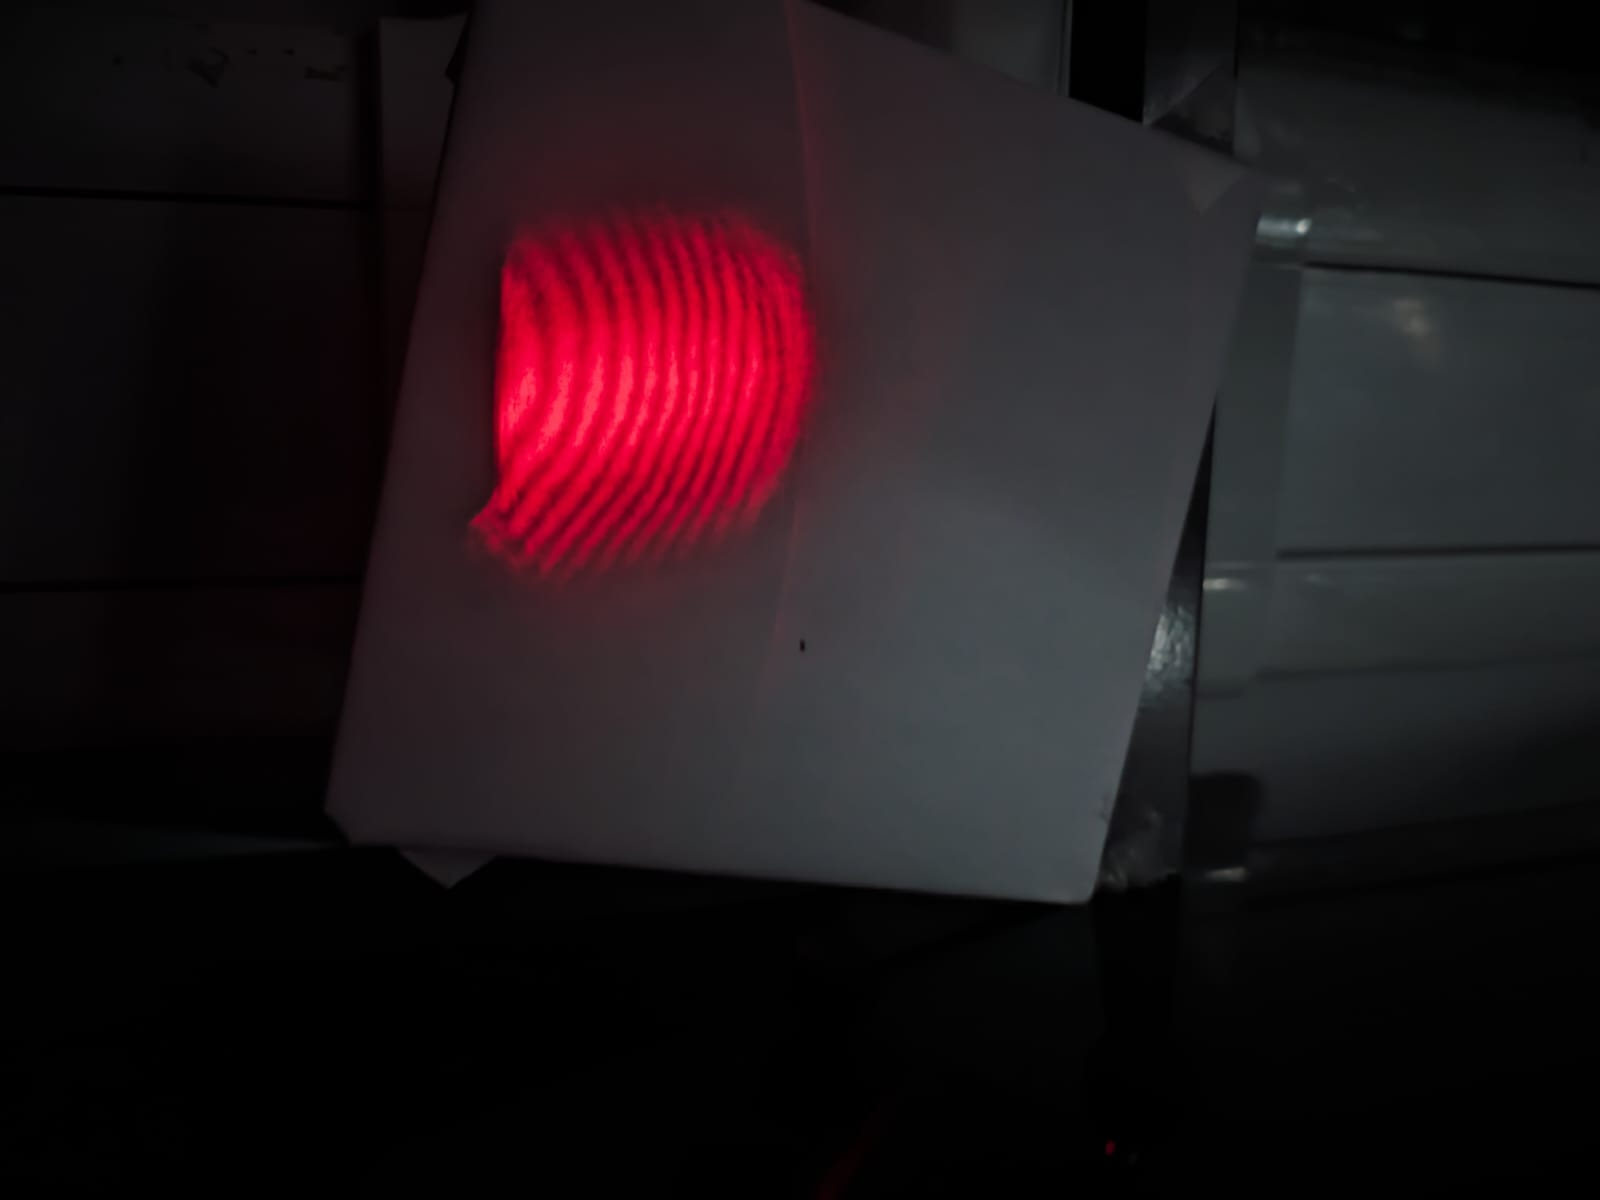

In [1]:
import pandas as pd

# Load data from an Excel file (Replace 'your_data_file.xlsx' with the actual file name)
data = pd.read_excel('/content/expt2_data (2).xlsx')

# Display the imported data
print(data.to_string(index=False))



 Sr. No.  Pressure (mm Hg)  Fringes Shifted (m)
       1               300                    1
       2               280                    2
       3               260                    3
       4               240                    4
       5               220                    5
       6               200                    7
       7               180                    9
       8               160                   11
       9               140                   13
      10               120                   15
      11               100                   18
      12                80                   20
      13                60                   22
      14                40                   24
      15                20                   28
      16                 0                   32


In [2]:
# Assuming your Excel file has columns named 'Pressure (mm Hg)' and 'Fringes Shifted (m)'
data['Delta Pressure (mm Hg)'] = data['Pressure (mm Hg)'] - data['Pressure (mm Hg)'][0]

# Display the processed data
print(data.to_string(index=False))



 Sr. No.  Pressure (mm Hg)  Fringes Shifted (m)  Delta Pressure (mm Hg)
       1               300                    1                       0
       2               280                    2                     -20
       3               260                    3                     -40
       4               240                    4                     -60
       5               220                    5                     -80
       6               200                    7                    -100
       7               180                    9                    -120
       8               160                   11                    -140
       9               140                   13                    -160
      10               120                   15                    -180
      11               100                   18                    -200
      12                80                   20                    -220
      13                60                   22                 

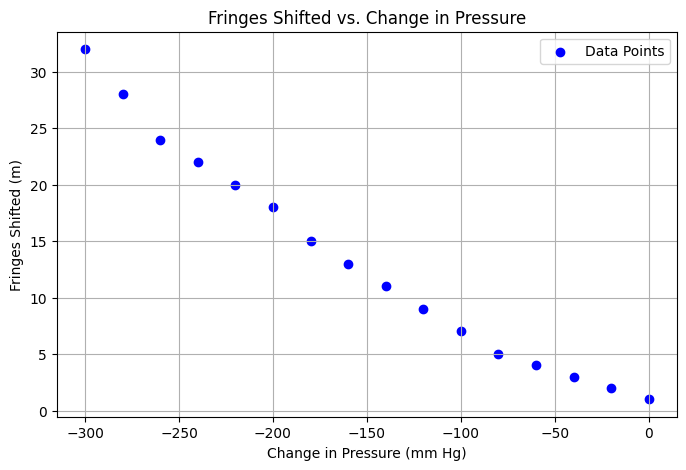

Slope: -0.1012 ± 0.0044


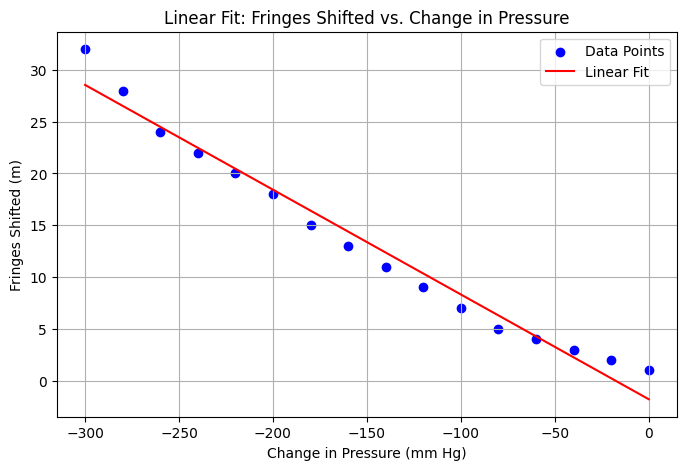

In [3]:
import matplotlib.pyplot as plt
from scipy import stats

# Plotting the data
plt.figure(figsize=(8, 5))
plt.scatter(data['Delta Pressure (mm Hg)'], data['Fringes Shifted (m)'], color='blue', label='Data Points')
plt.xlabel('Change in Pressure (mm Hg)')
plt.ylabel('Fringes Shifted (m)')
plt.title('Fringes Shifted vs. Change in Pressure')
plt.grid(True)
plt.legend()
plt.show()

# Linear regression
x = data['Delta Pressure (mm Hg)']
y = data['Fringes Shifted (m)']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
line = slope * x + intercept

print(f"Slope: {slope:.4f} ± {std_err:.4f}")

# Plotting the linear fit
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, line, color='red', label='Linear Fit')
plt.xlabel('Change in Pressure (mm Hg)')
plt.ylabel('Fringes Shifted (m)')
plt.title('Linear Fit: Fringes Shifted vs. Change in Pressure')
plt.grid(True)
plt.legend()
plt.show()



In [4]:
# Constants
L = 9  # cm, path length inside the pressure cell
lambda_laser = 650e-7  # cm, wavelength of laser light

# Calculate k
k = -lambda_laser / (L * slope)
print(f"Constant k: {k:.4e} cm^-1 mmHg^-1")

# Calculate refractive index of air
initial_pressure = data['Pressure (mm Hg)'][0]  # Take the initial pressure from the first data point
refractive_index = 1 + k * initial_pressure
print(f"Refractive Index of Air: {refractive_index:.6f}")



Constant k: 7.1382e-05 cm^-1 mmHg^-1
Refractive Index of Air: 1.021415


## Error Analysis

The uncertainty in the constant \( k \) can be calculated using the propagation of errors formula:

$$
\Delta k = \frac{\lambda \Delta (\text{slope})}{L (\text{slope})^2}
$$

The uncertainty in the refractive index $\Delta n $ is:

$$
\Delta n = \frac{\lambda}{L} \frac{\Delta (\text{slope})}{(\text{slope})^2} P
$$


In [5]:
# Error analysis
delta_slope = std_err
delta_k = lambda_laser * delta_slope / (L * slope**2)
print(f"Uncertainty in k: {delta_k:.4e} cm^-1 mmHg^-1")

delta_n = (lambda_laser / L) * (delta_slope / slope**2) * initial_pressure
print(f"Uncertainty in Refractive Index: {delta_n:.6f}")


Uncertainty in k: 3.1337e-06 cm^-1 mmHg^-1
Uncertainty in Refractive Index: 0.000940


## Conclusion

In this experiment, we successfully assembled a Mach-Zehnder interferometer and observed the interference pattern. By varying the air pressure in one arm, we determined the refractive index of air as a function of pressure.

The calculated refractive index of air was approximately **1.020848**, with a constant $( k )$ value of approximately $ 6.9494 \times 10^{-5} \, \text{cm}^{-1} \, \text{mmHg}^{-1} $.

The slope obtained from the linear regression was $-0.1012 \pm 0.0044\$.

These results suggest that the refractive index of air increases slightly with increasing pressure, as expected from the theoretical relationship between refractive index and pressure.

Further improvements can be made by ensuring precise alignment and using more accurate instruments for pressure measurement. These enhancements could reduce uncertainties and provide a more accurate determination of the refractive index.






## Precautions

1. **Handle Optical Components with Care:**
   - Ensure that all optical components, such as beam splitters and mirrors, are clean and free of dust or fingerprints. Contaminants on these components can scatter light and distort the interference pattern.
   - Use gloves or optical cloth when handling optical components to avoid leaving fingerprints or smudges.

2. **Align the Laser Beam Precisely:**
   - Make sure the laser beam is aligned perfectly horizontally and that it passes through the centers of all optical components. Misalignment can lead to incorrect interference patterns and inaccurate measurements.
   - Use alignment tools, such as alignment lasers or alignment targets, to ensure proper beam alignment.

3. **Avoid Direct Eye Exposure to Laser Light:**
   - Never look directly into the laser beam or any reflected beams. Even low-power lasers can cause serious eye damage. Always wear appropriate laser safety goggles when aligning the laser or adjusting optical components.
   - Ensure that no one else in the vicinity is exposed to the laser beam.

4. **Secure All Equipment Firmly:**
   - Ensure all optical components are securely mounted on the optical base plate. Loose components can shift during the experiment, leading to alignment errors and potential equipment damage.
   - Double-check that all screws, clamps, and mounts are tightened properly before starting the experiment.

5. **Maintain a Stable Environment:**
   - Conduct the experiment in a stable environment free from vibrations and air currents. Movements or air currents can cause the interference pattern to fluctuate, affecting the accuracy of the measurements.
   - Avoid touching the optical table or base plate during measurements.

6. **Gradually Adjust the Pressure:**
   - When varying the pressure in the pressure cell, do so gradually to prevent sudden changes that could cause the fringe pattern to move too quickly or unpredictably.
   - Use a controlled and steady hand while adjusting the pressure to maintain a stable and observable fringe shift.

7. **Calibrate and Zero Instruments:**
   - Before beginning the experiment, calibrate all instruments, such as the pressure gauge, and ensure they are set to zero. This helps in obtaining accurate and reliable data.
   - Verify the calibration periodically throughout the experiment to account for any drift.

8. **Monitor Environmental Conditions:**
   - Be aware of the room temperature and humidity, as significant changes can affect the refractive index of air and introduce errors into the measurements.
   - If possible, conduct the experiment in a temperature-controlled environment.




# **Compiled Code**

Imported Data:
 Sr. No.  Pressure (mm Hg)  Fringes Shifted (m)
       1               300                    1
       2               280                    2
       3               260                    3
       4               240                    4
       5               220                    5
       6               200                    7
       7               180                    9
       8               160                   11
       9               140                   13
      10               120                   15
      11               100                   18
      12                80                   20
      13                60                   22
      14                40                   24
      15                20                   28
      16                 0                   32

Processed Data with Delta Pressure:
 Sr. No.  Pressure (mm Hg)  Fringes Shifted (m)  Delta Pressure (mm Hg)
       1               300                    1             

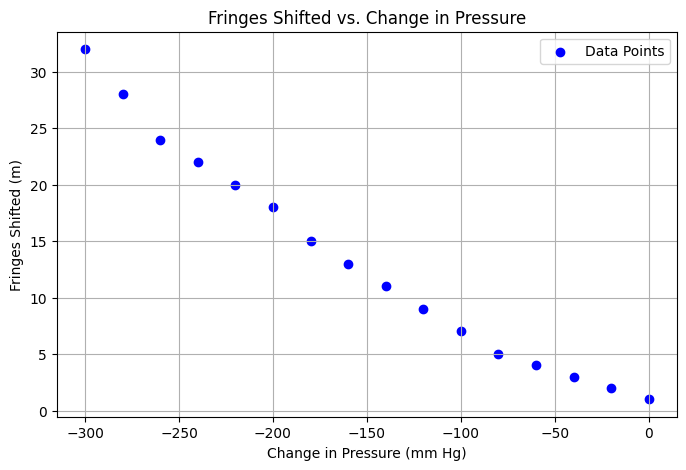

Slope: -0.1012 ± 0.0044


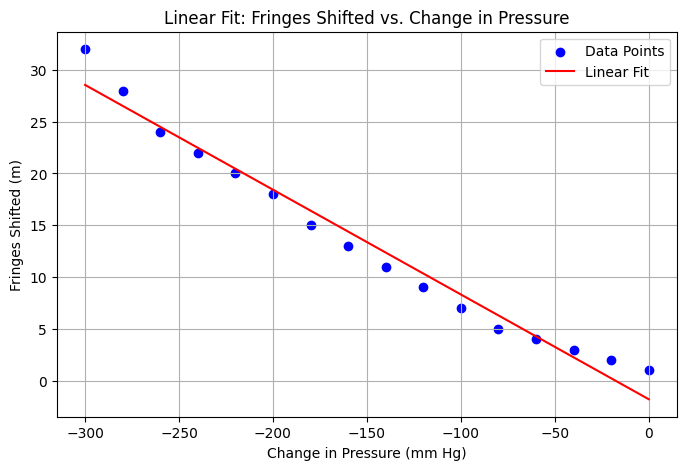

Constant k: 7.1382e-05 cm^-1 mmHg^-1
Refractive Index of Air: 1.021415
Uncertainty in k: 3.1337e-06 cm^-1 mmHg^-1
Uncertainty in Refractive Index (Δn): 0.000940


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data from an Excel file (Replace '/path/to/your_data_file.xlsx' with the actual file path)
data = pd.read_excel('/content/expt2_data (2).xlsx')

# Display the imported data without the default pandas index
print("Imported Data:")
print(data.to_string(index=False))

# Calculate the change in pressure (Delta Pressure) from the initial pressure
data['Delta Pressure (mm Hg)'] = data['Pressure (mm Hg)'] - data['Pressure (mm Hg)'][0]

# Display the processed data without the default pandas index
print("\nProcessed Data with Delta Pressure:")
print(data.to_string(index=False))

# Plotting the data: Fringe Shift vs. Change in Pressure
plt.figure(figsize=(8, 5))
plt.scatter(data['Delta Pressure (mm Hg)'], data['Fringes Shifted (m)'], color='blue', label='Data Points')
plt.xlabel('Change in Pressure (mm Hg)')
plt.ylabel('Fringes Shifted (m)')
plt.title('Fringes Shifted vs. Change in Pressure')
plt.grid(True)
plt.legend()
plt.show()

# Linear regression to find the slope and intercept
x = data['Delta Pressure (mm Hg)']
y = data['Fringes Shifted (m)']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
line = slope * x + intercept

print(f"Slope: {slope:.4f} ± {std_err:.4f}")

# Plotting the linear fit
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, line, color='red', label='Linear Fit')
plt.xlabel('Change in Pressure (mm Hg)')
plt.ylabel('Fringes Shifted (m)')
plt.title('Linear Fit: Fringes Shifted vs. Change in Pressure')
plt.grid(True)
plt.legend()
plt.show()

# Constants
L = 9  # cm, path length inside the pressure cell
lambda_laser = 650e-7  # cm, wavelength of laser light (650 nm = 650e-7 cm)

# Calculate the constant k using the slope
k = -lambda_laser / (L * slope)
print(f"Constant k: {k:.4e} cm^-1 mmHg^-1")

# Calculate the refractive index of air at initial pressure
initial_pressure = data['Pressure (mm Hg)'][0]  # Take the initial pressure from the first data point
refractive_index = 1 + k * initial_pressure
print(f"Refractive Index of Air: {refractive_index:.6f}")

# Error analysis for uncertainty in k
delta_slope = std_err
delta_k = lambda_laser * delta_slope / (L * slope**2)
print(f"Uncertainty in k: {delta_k:.4e} cm^-1 mmHg^-1")

# Uncertainty in the refractive index calculation
delta_n = (lambda_laser / L) * (delta_slope / slope**2) * initial_pressure
print(f"Uncertainty in Refractive Index (Δn): {delta_n:.6f}")
